In [2]:
import os, math, random, warnings, ast, gc
import numpy as np, pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt, matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm import tqdm
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [3]:
FS          = 100          # Hz (100Hz version of PTB-XL)
TOTAL_SAMP  = 1000         # 10 seconds
N_LEADS     = 12
NC          = 2            # NORM=0, ABNORMAL=1

WIN_SAMP    = 50           # 500ms per window — covers P-QRS-T at 70bpm
WIN_STRIDE  = 25           # 250ms stride (50% overlap) -> smooth SAT curve
T           = (TOTAL_SAMP - WIN_SAMP) // WIN_STRIDE + 1   # = 39 windows
# Timing: window t ends at (t*WIN_STRIDE + WIN_SAMP)/FS seconds
#   t=0: 0.5s, t=38: (38*25+50)/100=10.0s

FEAT_DIM    = 64
ORDER       = 3            # W=4 windows × 250ms stride = context ≈ 1.25s (≥2 beats)
EFF_T       = T - ORDER    # = 36 TANDEM steps, each = 250ms of new ECG
W           = ORDER + 1    # = 4

HIDDEN      = 128
# TandemLSTM is 1-layer; set width so param count matches 2-layer FullLSTM.
# With HIDDEN=128 (2-layer): 231,682 params.
# With HIDDEN_TANDEM=210 (1-layer): 231,678 params  (~equal).
HIDDEN_TANDEM = 210
DROPOUT_P   = 0.25
MAX_NORM    = 1.0

LR_P1 = 1e-4;  EP_P1 = 120;  BS_P1 = 256;  PAT_P1 = 25
LR_P2 = 1e-4;  BS_P2 = 64;  PAT_P2 = 40
EP_SPRT = 200; W_MCE = 0.7; W_LLLR = 0.3  # LLLR weighted higher
EP_COMP = 120  # comparison methods

LAMBDA_E    = 0.30   # EARLIEST earliness weight
TEAS_CTHR   = 0.80   # TEASER stop-label confidence threshold

ALPHA, BETA = 0.05, 0.05
A_WALD = math.log((1-BETA)/ALPHA)    # +2.944
B_WALD = math.log(BETA/(1-ALPHA))   # -2.944

print(f'T={T} windows  WIN={WIN_SAMP/FS*1000:.0f}ms  STRIDE={WIN_STRIDE/FS*1000:.0f}ms')
print(f'ORDER={ORDER}  W={W}  EFF_T={EFF_T}')
print(f'Context per TANDEM window: {W*WIN_STRIDE/FS*1000:.0f}ms = {W*WIN_STRIDE/FS:.2f}s')
print(f'First TANDEM decision at window {ORDER}: '
      f'{(ORDER*WIN_STRIDE+WIN_SAMP)/FS:.2f}s into recording')
print(f'Wald: A={A_WALD:+.3f}  B={B_WALD:+.3f}')

MAX_S = T * WIN_STRIDE / FS


T=39 windows  WIN=500ms  STRIDE=250ms
ORDER=3  W=4  EFF_T=36
Context per TANDEM window: 1000ms = 1.00s
First TANDEM decision at window 3: 1.25s into recording
Wald: A=+2.944  B=-2.944


In [4]:
import kagglehub, wfdb
path = kagglehub.dataset_download("khyeh0719/ptb-xl-dataset") +'/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1'
db  = pd.read_csv(os.path.join(path,'ptbxl_database.csv'),index_col='ecg_id')
scp = pd.read_csv(os.path.join(path,'scp_statements.csv'),index_col=0)
diag = scp[scp['diagnostic']==1]

def superclass(s):
            codes = ast.literal_eval(s)
            d = {k:v for k,v in codes.items() if k in diag.index}
            if not d: return None
            return diag.loc[max(d,key=d.get),'diagnostic_class']

db['sc'] = db['scp_codes'].apply(superclass)
db = db.dropna(subset=['sc'])
db['y'] = (db['sc'] != 'NORM').astype(int)

sigs = []
for _, row in tqdm(db.iterrows(), total=len(db), desc='Loading WFDB'):
            rec = wfdb.rdrecord(os.path.join(path, row['filename_lr']))
            sigs.append(rec.p_signal.astype(np.float32))

signals = np.array(sigs)   # (n, 1000, 12)
y_all = db['y'].values.astype(np.int64)
folds_all = db['strat_fold'].values
print(f'[PTB-XL real]  n={len(y_all)}  NORM={np.sum(y_all==0)}  ABNORM={np.sum(y_all==1)}')

print(f'Signal shape: {signals.shape}   dtype={signals.dtype}')
print(f'Class balance: NORM={np.sum(y_all==0)}  ABNORM={np.sum(y_all==1)}')

Using Colab cache for faster access to the 'ptb-xl-dataset' dataset.


Loading WFDB: 100%|██████████| 21430/21430 [07:57<00:00, 44.85it/s]


[PTB-XL real]  n=21430  NORM=9260  ABNORM=12170
Signal shape: (21430, 1000, 12)   dtype=float32
Class balance: NORM=9260  ABNORM=12170


In [5]:
from torch.utils.data import Dataset

tr_idx = np.where(folds_all <= 8)[0]
va_idx = np.where(folds_all == 9)[0]
te_idx = np.where(folds_all == 10)[0]
y_train = y_all[tr_idx]; y_val = y_all[va_idx]; y_test = y_all[te_idx]

for nm, y in [('Train',y_train),('Val',y_val),('Test',y_test)]:
    c = np.bincount(y)
    print(f'{nm:5s}: {len(y):5d}  NORM={c[0]:4d}  ABNORM={c[1]:4d}  ratio={c[1]/c[0]:.2f}')

rng_sc = np.random.default_rng(SEED)
samp_recs = rng_sc.choice(tr_idx, min(400, len(tr_idx)), replace=False)
samp_flat = np.vstack([
    signals[r, t*WIN_STRIDE : t*WIN_STRIDE+WIN_SAMP, :]
    for r in samp_recs for t in range(T)
]).astype(np.float32)
scaler = StandardScaler().fit(samp_flat)
del samp_flat; gc.collect()
print(f'Scaler fitted on {len(samp_recs)} recordings × {T} windows')

n_n, n_a = np.bincount(y_train)
CLASS_WT  = torch.tensor([n_a/n_n, 1.0], dtype=torch.float32).to(device)
print(f'Class weights: NORM={CLASS_WT[0]:.3f}  ABNORM={CLASS_WT[1]:.3f}')

# ── Lazy WindowDataset: no RAM beyond one window per call ─────────────────────
class WindowDataset(Dataset):
    """
    Extracts one (N_LEADS, WIN_SAMP) scaled window on demand.
    RAM cost: O(1) per call, NOT O(n*T).
    """
    def __init__(self, sigs, rec_idx, labels, sc):
        self.sigs = sigs        # shared reference to (n_all, 1000, 12)
        self.idx  = rec_idx     # indices into sigs
        self.y    = labels
        self.sc   = sc
    def __len__(self):
        return len(self.idx) * T
    def __getitem__(self, flat_i):
        ri  = flat_i // T; ti = flat_i % T
        rec = self.idx[ri]
        s   = ti * WIN_STRIDE
        w   = self.sigs[rec, s:s+WIN_SAMP, :]        # (WIN_SAMP, N_LEADS)
        wsc = self.sc.transform(w).T.astype(np.float32)  # (N_LEADS, WIN_SAMP)
        return torch.tensor(wsc), torch.tensor(int(self.y[ri]), dtype=torch.long)

p1_ld = DataLoader(WindowDataset(signals, tr_idx, y_train, scaler),
                   BS_P1, shuffle=True,  num_workers=2, pin_memory=True)
p1_va = DataLoader(WindowDataset(signals, va_idx, y_val,   scaler),
                   BS_P1, shuffle=False, num_workers=2, pin_memory=True)
print(f'WindowDataset  train={len(tr_idx)*T:,} windows  val={len(va_idx)*T:,} windows')

Train: 17111  NORM=7397  ABNORM=9714  ratio=1.31
Val  :  2156  NORM= 930  ABNORM=1226  ratio=1.32
Test :  2163  NORM= 933  ABNORM=1230  ratio=1.32
Scaler fitted on 400 recordings × 39 windows
Class weights: NORM=1.313  ABNORM=1.000
WindowDataset  train=667,329 windows  val=84,084 windows


In [6]:
class ResBlock1D(nn.Module):
    def __init__(self, i, o, stride=1, k=7):
        super().__init__(); p=k//2
        self.c1=nn.Conv1d(i,o,k,stride=stride,padding=p,bias=False); self.b1=nn.BatchNorm1d(o)
        self.c2=nn.Conv1d(o,o,k,padding=p,bias=False);               self.b2=nn.BatchNorm1d(o)
        self.sc=(nn.Sequential(nn.Conv1d(i,o,1,stride=stride,bias=False),nn.BatchNorm1d(o))
                 if stride!=1 or i!=o else nn.Identity())
    def forward(self,x): return F.relu(self.b2(self.c2(F.relu(self.b1(self.c1(x)))))+self.sc(x))

class WindowCNN(nn.Module):
    """
    Per-window feature extractor for 12-lead × 50-sample (500ms) ECG windows.
    forward() -> (B, NC)       class logits for Phase-1 CE training
    features() -> (B, FEAT_DIM) feature vectors for Phase-2 input
    """
    def __init__(self, leads=N_LEADS, win=WIN_SAMP, fd=FEAT_DIM, nc=NC, drop=DROPOUT_P):
        super().__init__()
        # Multi-scale branches (9=90ms, 19=190ms, 39=390ms kernels)
        br = lambda k: nn.Sequential(
            nn.Conv1d(leads,32,k,padding=k//2,bias=False), nn.BatchNorm1d(32), nn.ReLU())
        self.fine  = br(9)   # QRS spikes
        self.med   = br(19)  # QRS complex
        self.coarse= br(39)  # P-QRS-T shape
        self.fuse  = ResBlock1D(96, fd, stride=2, k=7)   # (B,96,50)->(B,fd,25)
        self.gap   = nn.AdaptiveAvgPool1d(1)
        self.drop  = nn.Dropout(drop)
        self.clf   = nn.Linear(fd, nc)                   # Phase-1 classification

    def features(self, x):          # x:(B,12,50) -> (B,FEAT_DIM)
        cat = torch.cat([self.fine(x), self.med(x), self.coarse(x)], 1)  # (B,96,50)
        return self.gap(self.fuse(cat)).squeeze(-1)      # (B,FEAT_DIM)

    def forward(self, x):           # -> (B,NC)
        return self.clf(self.drop(self.features(x)))

cnn = WindowCNN().to(device)
print(f'WindowCNN params: {sum(p.numel() for p in cnn.parameters()):,}')


WindowCNN params: 104,258


In [7]:
opt1 = optim.AdamW(cnn.parameters(), lr=LR_P1, weight_decay=1e-4)
sch1 = optim.lr_scheduler.CosineAnnealingLR(opt1, T_max=EP_P1, eta_min=1e-6)
best1, pat1 = 0., 0
for ep in range(EP_P1):
    cnn.train(); el = 0.
    for xb, yb in p1_ld:
        xb, yb = xb.to(device), yb.to(device)
        opt1.zero_grad()
        loss = F.cross_entropy(cnn(xb), yb, weight=CLASS_WT, label_smoothing=0.05)
        loss.backward(); nn.utils.clip_grad_norm_(cnn.parameters(), MAX_NORM)
        opt1.step(); el += loss.item()
    sch1.step(); cnn.eval()
    pv = []
    with torch.no_grad():
        for xb_v, _ in p1_va:
            pv.append(cnn(xb_v.to(device)).argmax(1).cpu())
    pv  = torch.cat(pv).numpy()
    yv  = np.repeat(y_val, T)
    vb  = balanced_accuracy_score(yv, pv)
    if vb - best1 > 1e-3:
        best1 = vb; pat1 = 0; torch.save(cnn.state_dict(), 'cnn.pth')
    else: pat1 += 1
    if (ep+1) % 10 == 0:
        print(f'  ep {ep+1:3d}  loss={el/len(p1_ld):.4f}  val_bacc={vb:.4f}  best={best1:.4f}')
    if pat1 >= PAT_P1: print(f'  Early stop ep {ep+1}'); break
cnn.load_state_dict(torch.load('cnn.pth', weights_only=True))
cnn.eval()
print(f'Phase-1 best val balanced_acc: {best1:.4f}')

MAX_S = T * WIN_STRIDE / FS


  ep  10  loss=0.3885  val_bacc=0.8095  best=0.8133
  ep  20  loss=0.3663  val_bacc=0.8147  best=0.8150
  ep  30  loss=0.3509  val_bacc=0.8079  best=0.8150
  ep  40  loss=0.3393  val_bacc=0.8045  best=0.8150
  Early stop ep 40
Phase-1 best val balanced_acc: 0.8150


In [8]:
BATCH_RECS = 32
CNN_BS     = 512         # CNN sub-batch (windows)

@torch.no_grad()
def extract_streaming(cnn_model, sigs, rec_idx, sc):
    n     = len(rec_idx)
    F_out = np.zeros((n, T, FEAT_DIM), dtype=np.float32)
    for i in tqdm(range(0, n, BATCH_RECS), desc='Extracting', leave=True):
        batch = rec_idx[i : i + BATCH_RECS]; bn = len(batch)

        raw_wins = np.stack([
            np.stack([sigs[r, t*WIN_STRIDE : t*WIN_STRIDE+WIN_SAMP, :]
                      for t in range(T)])          # (T, WIN_SAMP, N_LEADS)
            for r in batch
        ])                                         # (bn, T, WIN_SAMP, N_LEADS)

        flat_sc = sc.transform(
            raw_wins.reshape(-1, N_LEADS)          # (bn*T*WIN_SAMP, N_LEADS)
        ).reshape(bn, T, WIN_SAMP, N_LEADS)

        wins = flat_sc.transpose(0, 1, 3, 2)      # (bn, T, N_LEADS, WIN_SAMP)
        flat_t = torch.tensor(
            wins.reshape(-1, N_LEADS, WIN_SAMP), dtype=torch.float32)

        feats = np.concatenate([
            cnn_model.features(flat_t[j : j+CNN_BS].to(device)).cpu().numpy()
            for j in range(0, len(flat_t), CNN_BS)
        ])                                         # (bn*T, FEAT_DIM)
        F_out[i : i+bn] = feats.reshape(bn, T, FEAT_DIM)
    return F_out

print('Extracting features (streaming, vectorised scaler) ...')
F_train = extract_streaming(cnn, signals, tr_idx, scaler)
print(f'  F_train {F_train.shape}')
F_val   = extract_streaming(cnn, signals, va_idx, scaler)
F_test  = extract_streaming(cnn, signals, te_idx, scaler)

# Keep ONLY test signals for online inference
te_signals_raw = signals[te_idx].copy()      # (n_te, 1000, N_LEADS)
print(f'te_signals_raw kept: {te_signals_raw.shape}')
del signals; gc.collect()

def seq_ld(F, y, shuffle=True, dl=False):
    ds = TensorDataset(torch.tensor(F, dtype=torch.float32),
                       torch.tensor(y, dtype=torch.long))
    return DataLoader(ds, BS_P2, shuffle=shuffle, drop_last=dl, num_workers=0)

tr_ld = seq_ld(F_train, y_train, True,  True)
va_ld = seq_ld(F_val,   y_val,   False)
te_ld = seq_ld(F_test,  y_test,  False)


Extracting features (streaming, vectorised scaler) ...


Extracting: 100%|██████████| 535/535 [00:08<00:00, 62.21it/s]


  F_train (17111, 39, 64)


Extracting: 100%|██████████| 68/68 [00:00<00:00, 68.04it/s]


te_signals_raw kept: (2163, 1000, 12)


In [9]:
#  B2Bsqrt activation (Ebihara et al. 2021): gradient-stable LSTM cell
def b2b(x, a=1.0):
    at=x.new_tensor(a)
    return x.sign()*(torch.sqrt(at+x.abs())-torch.sqrt(at))

class TandemLSTM(nn.Module):
    def __init__(self, inp, hid):
        super().__init__(); self.H=hid
        self.g=nn.Linear(inp+hid,4*hid)
        nn.init.orthogonal_(self.g.weight[:2*hid]); nn.init.xavier_uniform_(self.g.weight[2*hid:])
        nn.init.zeros_(self.g.bias); nn.init.ones_(self.g.bias[hid:2*hid])
    def forward(self,x):
        B,L,_=x.shape; h=x.new_zeros(B,self.H); c=x.new_zeros(B,self.H); out=[]
        for t in range(L):
            f,i,g,o=self.g(torch.cat([x[:,t],h],1)).chunk(4,1)
            c=torch.sigmoid(f)*c+torch.sigmoid(i)*b2b(g)
            h=torch.sigmoid(o)*b2b(c); out.append(h.unsqueeze(1))
        return torch.cat(out,1)

#  SPRTTandem — sliding-window integrator
class SPRTTandem(nn.Module):
    """
    Processes feature sequences via sliding windows of length W=ORDER+1.
    Each window is fed independently (zero-initial LSTM state) to TandemLSTM.
    The TANDEM formula corrects for overlapping context across windows.
    """
    def __init__(self, fd=FEAT_DIM, nc=NC, order=ORDER, hid=HIDDEN_TANDEM, drop=DROPOUT_P):
        super().__init__()
        self.order=order; self.W=order+1; self.eff_T=T-order; self.nc=nc
        self.pos_enc=nn.Parameter(torch.randn(order+1,fd)*0.01)
        self.lstm=TandemLSTM(fd,hid)
        self.drop=nn.Dropout(drop)
        self.head=nn.Linear(hid,nc)

    def forward(self,x):
        """x:(B,T,fd) -> logits_flat(B*eff_T,W,nc), logits_struct(B,eff_T,W,nc)"""
        B,T_,F=x.shape; W,eT=self.W,self.eff_T
        wins = x.unfold(1,W,1).permute(0,1,3,2)+self.pos_enc.view(1,1,W,F)
        xf   = wins.reshape(B*eT,W,F)
        hf   = self.lstm(xf)
        lf   = self.head(self.drop(hf))           # (B*eT,W,nc)
        return lf, lf.view(B,eT,W,self.nc)

integrator = SPRTTandem().to(device)
n_i = sum(p.numel() for p in integrator.parameters())
print(f'SPRTTandem params: {n_i:,}  ORDER={ORDER}  W={W}  EFF_T={EFF_T}')

SPRTTandem params: 231,678  ORDER=3  W=4  EFF_T=36


In [10]:
def compute_tandem_llrs(ls, order):
    """ls: (B,eff_T,W,nc) -> Λ (B,eff_T,nc,nc)"""
    lf = ls[:,:,-1,:]    # full-window logit  (B,eff_T,nc)
    lp = ls[:,:,-2,:]    # prefix logit        (B,eff_T,nc)

    # Window 0: initialise with FULL joint LLR (not increment)
    d0 = lf[:,0:1,:].unsqueeze(-1) - lf[:,0:1,:].unsqueeze(-2)     # (B,1,nc,nc)

    # Windows ≥1: TANDEM increment
    dc   = lf[:,1:,:] - lp[:,1:,:]                                  # (B,eff_T-1,nc)
    d1n  = dc.unsqueeze(-1) - dc.unsqueeze(-2)                     # (B,eff_T-1,nc,nc)

    delta = torch.cat([d0, d1n], dim=1)                            # (B,eff_T,nc,nc)
    eye   = torch.eye(delta.shape[-1],device=delta.device).view(1,1,delta.shape[-1],delta.shape[-1])
    delta = delta - 1e-9*eye                                       # tie-breaking
    return torch.cumsum(delta,dim=1)                               # (B,eff_T,nc,nc)

def multiplet_ce(logits_flat, labels, eff_T, weight=None):
    """CE over all positions in all windows."""
    B_eff,W_,nc = logits_flat.shape; B=B_eff//eff_T
    lg2 = logits_flat.reshape(-1,nc)
    lr  = labels.unsqueeze(1).expand(B,eff_T).reshape(-1).unsqueeze(1).expand(-1,W_).reshape(-1)
    return F.cross_entropy(lg2,lr,weight=weight)

def lllr_loss(llrs, labels):
    """
    LLLR applied to CUMULATIVE TANDEM LLR Λ_t (NOT instantaneous logits).
    This is the key loss: forces σ(Λ_{t,j,k}) -> 1_{y=j} at every step t.
    Without this the LLR grows at an incorrect rate and the Wald bound loses validity.
    """
    B,eT,nc,_ = llrs.shape
    coeff = nc/(2.0*(nc-1.0))
    y_oh  = F.one_hot(labels,nc).float().view(B,1,nc,1)
    diff  = torch.abs(y_oh - torch.sigmoid(llrs))
    eye   = torch.eye(nc,device=llrs.device).view(1,1,nc,nc)
    return coeff*(diff*(1-eye)).sum()/(B*eT*nc*(nc-1))


In [11]:
opt_i = optim.AdamW(integrator.parameters(), lr=LR_P2, weight_decay=1e-4)
sch_i = optim.lr_scheduler.ReduceLROnPlateau(opt_i,'max',factor=0.5,patience=20,min_lr=1e-6)
best_i, pat_i = 0., 0
hist_i = {'loss':[],'mce':[],'lllr':[],'vb':[]}

print(f'Phase 2 — SPRTTandem  W_MCE={W_MCE} W_LLLR={W_LLLR}')
for ep in range(EP_SPRT):
    integrator.train(); etot=emce=ell=0.
    for xb,yb in tr_ld:
        xb,yb=xb.to(device),yb.to(device); opt_i.zero_grad()
        lf,ls = integrator(xb)
        llrs  = compute_tandem_llrs(ls, ORDER)           # (B,EFF_T,nc,nc)
        mce   = multiplet_ce(lf, yb, EFF_T, CLASS_WT)
        ll    = lllr_loss(llrs, yb)                      # on CUMULATIVE LLR
        loss  = W_MCE*mce + W_LLLR*ll
        loss.backward(); nn.utils.clip_grad_norm_(integrator.parameters(),MAX_NORM)
        opt_i.step(); etot+=loss.item(); emce+=mce.item(); ell+=ll.item()
    # Validate: last TANDEM step decision (offline proxy)
    integrator.eval(); pv,lv=[],[]
    with torch.no_grad():
        for xb_v,yb_v in va_ld:
            _,ls_v=integrator(xb_v.to(device))
            llrs_v=compute_tandem_llrs(ls_v,ORDER)
            pv.append((llrs_v[:,-1,1,0]>0).long().cpu()); lv.append(yb_v)
    vb=balanced_accuracy_score(torch.cat(lv).numpy(),torch.cat(pv).numpy())
    sch_i.step(vb)
    nb=len(tr_ld)
    hist_i['loss'].append(etot/nb); hist_i['mce'].append(emce/nb)
    hist_i['lllr'].append(ell/nb); hist_i['vb'].append(vb)
    if vb-best_i>5e-4: best_i=vb; pat_i=0; torch.save(integrator.state_dict(),'integ.pth')
    else: pat_i+=1
    if (ep+1)%25==0 or ep==0:
        print(f'  ep {ep+1:3d}  loss={etot/nb:.4f} '
              f'[mce={emce/nb:.4f} lllr={ell/nb:.4f}]  val_bacc={vb:.4f}  best={best_i:.4f}')
    if pat_i>=PAT_P2: print(f'  Early stop ep {ep+1}'); break
integrator.load_state_dict(torch.load('integ.pth',weights_only=True)); integrator.eval()
print(f'Best val balanced_acc: {best_i:.4f}')


Phase 2 — SPRTTandem  W_MCE=0.7 W_LLLR=0.3
  ep   1  loss=0.4326 [mce=0.5185 lllr=0.2323]  val_bacc=0.8614  best=0.8614
  ep  25  loss=0.1905 [mce=0.2400 lllr=0.0751]  val_bacc=0.8624  best=0.8620
  Early stop ep 46
Best val balanced_acc: 0.8620


In [12]:
@torch.no_grad()
def collect_last_logit(model, loader):
    lg,lb=[],[]
    for xb,yb in loader:
        _,ls=model(xb.to(device))
        lg.append(ls[:,-1,-1,:].cpu()); lb.append(yb)  # last window, last position
    return torch.cat(lg),torch.cat(lb)

val_lg,val_lb=collect_last_logit(integrator,va_ld)
T_sc=nn.Parameter(torch.ones(1))
opt_T=optim.LBFGS([T_sc],lr=0.1,max_iter=300)
def cl():
    opt_T.zero_grad(); l=F.cross_entropy(val_lg/T_sc.clamp(min=0.05),val_lb); l.backward(); return l
opt_T.step(cl)
T_STAR=float(T_sc.item())

def ece(lg,lb,b=10):
    p=torch.softmax(lg,1).numpy(); y=lb.numpy(); c=p.max(1); pr=p.argmax(1); tot=0.
    for lo,hi in zip(np.linspace(0,1,b+1)[:-1],np.linspace(0,1,b+1)[1:]):
        m=(c>=lo)&(c<hi)
        if m.sum()==0: continue
        tot+=m.mean()*abs((pr[m]==y[m]).mean()-c[m].mean())
    return tot
print(f'T*={T_STAR:.4f}  ECE before={ece(val_lg,val_lb):.4f}  after={ece(val_lg/T_STAR,val_lb):.4f}')
# Effective Wald bounds after calibration
A_EFF = A_WALD / T_STAR; B_EFF = B_WALD / T_STAR
print(f'Effective Wald after T* scaling: A_eff={A_EFF:+.4f}  B_eff={B_EFF:+.4f}')


T*=2.0118  ECE before=0.0815  after=0.0093
Effective Wald after T* scaling: A_eff=+1.4636  B_eff=-1.4636


In [13]:
class FullLSTM(nn.Module):
    """Shared backbone for CONFIDENCE / EARLIEST / TEASER."""
    def __init__(self, fd=FEAT_DIM, hid=HIDDEN, nc=NC, drop=DROPOUT_P):
        super().__init__()
        self.lstm=nn.LSTM(fd,hid,2,batch_first=True,dropout=drop)
        self.drop=nn.Dropout(drop); self.clf=nn.Linear(hid,nc)
    def forward_all(self,x):      # (B,T,fd) -> (B,T,nc)
        h,_=self.lstm(x); return self.clf(self.drop(h))
    def forward(self,x):          # last step only -> (B,nc)
        return self.forward_all(x)[:,-1,:]
    def step(self,feat,state):    # online: (1,fd),(h,c) -> (1,nc),state
        h,state=self.lstm(feat.unsqueeze(1),state)
        return self.clf(self.drop(h.squeeze(1))),state

class EARLModel(FullLSTM):
    """EARLIEST-S: adds a learnable halting head."""
    def __init__(self): super().__init__(); self.halt=nn.Linear(HIDDEN,1)
    def forward_halt(self,x):
        h,_=self.lstm(x); return self.clf(self.drop(h)),torch.sigmoid(self.halt(h)).squeeze(-1)
    def step(self,feat,state):
        h,state=self.lstm(feat.unsqueeze(1),state)
        logit=self.clf(self.drop(h.squeeze(1)))
        halt =torch.sigmoid(self.halt(h.squeeze(1))).squeeze(-1)
        return logit,halt,state

class TEASModel(FullLSTM):
    """TEASER-S: adds a learned stopping trigger."""
    def __init__(self): super().__init__(); self.stop=nn.Linear(HIDDEN,1)
    def forward_stop(self,x):
        h,_=self.lstm(x); return self.clf(self.drop(h)),self.stop(self.drop(h)).squeeze(-1)
    def step(self,feat,state):
        h,state=self.lstm(feat.unsqueeze(1),state)
        logit=self.clf(self.drop(h.squeeze(1)))
        stop =torch.sigmoid(self.stop(self.drop(h.squeeze(1)))).squeeze(-1)
        return logit,stop,state
    def freeze_bk(self):
        for p in list(self.lstm.parameters())+list(self.clf.parameters()): p.requires_grad_(False)
    def unfreeze(self):
        for p in self.parameters(): p.requires_grad_(True)

conf_m = FullLSTM().to(device); earl_m = EARLModel().to(device); teas_m = TEASModel().to(device)
for nm,m in [('CONF',conf_m),('EARL',earl_m),('TEAS',teas_m)]:
    print(f'{nm}: {sum(p.numel() for p in m.parameters()):,} params')


CONF: 231,682 params
EARL: 231,811 params
TEAS: 231,811 params


In [14]:

def seqce(logits, labels, weight=None):
    """MultipletCE for full-sequence (B,T,nc) outputs of FullLSTM family.
    multiplet_ce expects (B*eff_T,W,nc) — the TANDEM sliding-window shape.
    TEASER/EARLIEST forward_stop/forward_halt output (B,T,nc) — use this instead.
    """
    B, T_, nc_ = logits.shape
    return F.cross_entropy(
        logits.reshape(-1, nc_),
        labels.unsqueeze(1).expand(B, T_).reshape(-1),
        weight=weight)

def train_generic(model, ld, vald, epochs, patience, loss_fn, tag):
    opt=optim.AdamW([p for p in model.parameters() if p.requires_grad],lr=LR_P2,weight_decay=1e-4)
    sch=optim.lr_scheduler.ReduceLROnPlateau(opt,'max',factor=0.5,patience=15,min_lr=1e-6)
    best,pat=0.,0
    for ep in range(epochs):
        model.train(); el=0.
        for xb,yb in ld:
            xb,yb=xb.to(device),yb.to(device); opt.zero_grad()
            loss=loss_fn(model,xb,yb); loss.backward()
            nn.utils.clip_grad_norm_([p for p in model.parameters() if p.requires_grad],MAX_NORM)
            opt.step(); el+=loss.item()
        model.eval(); pv,lv=[],[]
        with torch.no_grad():
            for xb_v,yb_v in vald:
                out=model(xb_v.to(device)); lg=out[0] if isinstance(out,tuple) else out
                pv.append(lg.argmax(1).cpu()); lv.append(yb_v)
        vb=balanced_accuracy_score(torch.cat(lv).numpy(),torch.cat(pv).numpy())
        sch.step(vb)
        if vb-best>5e-4: best=vb; pat=0; torch.save(model.state_dict(),f'{tag}.pth')
        else: pat+=1
        if (ep+1)%25==0 or ep==0: print(f'  [{tag}] ep {ep+1:3d}  loss={el/len(ld):.4f}  val={vb:.4f}  best={best:.4f}')
        if pat>=patience: print(f'  [{tag}] early stop ep {ep+1}'); break
    model.load_state_dict(torch.load(f'{tag}.pth',weights_only=True)); model.eval()
    return best

print('Training CONFIDENCE ...')
best_conf = train_generic(conf_m, tr_ld, va_ld, EP_COMP, PAT_P2,
    lambda m,xb,yb: F.cross_entropy(m(xb),yb,weight=CLASS_WT), 'conf')

def earl_loss(m,xb,yb):
    lg,halt=m.forward_halt(xb)
    B,T_,nc=lg.shape
    ce=F.cross_entropy(lg.reshape(-1,nc),yb.unsqueeze(1).expand(B,T_).reshape(-1),weight=CLASS_WT)
    log1mh=torch.log(1-halt+1e-7)
    lsurv=torch.zeros_like(log1mh); lsurv[:,1:]=torch.cumsum(log1mh[:,:-1],1)
    p_halt=halt*torch.exp(lsurv)
    t_ax=torch.arange(T_,dtype=torch.float32,device=halt.device)/(T_-1)
    return ce + LAMBDA_E*(p_halt*t_ax).sum(1).mean()

print('Training EARLIEST-S ...')
best_earl = train_generic(earl_m, tr_ld, va_ld, EP_COMP, PAT_P2, earl_loss, 'earl')

print('Training TEASER Stage 1 ...')
best_teas1 = train_generic(teas_m, tr_ld, va_ld, EP_COMP, PAT_P2,
    lambda m,xb,yb: seqce(m.forward_stop(xb)[0], yb, CLASS_WT), 'teas1')

teas_m.freeze_bk()
stop_lbl_list=[]
teas_m.eval()
with torch.no_grad():
    for xb,_ in DataLoader(TensorDataset(torch.tensor(F_train),torch.tensor(y_train)),256,False):
        lg,_=teas_m.forward_stop(xb.to(device))
        final=lg[:,-1,:].argmax(-1); preds=lg.argmax(-1); confs=lg.softmax(-1).max(-1)[0]
        sl=((preds==final.unsqueeze(1))&(confs>=TEAS_CTHR)).float(); stop_lbl_list.append(sl.cpu())
stop_lbl=torch.cat(stop_lbl_list,0)
pos_w=torch.tensor((stop_lbl==0).float().mean()/max((stop_lbl==1).float().mean(),1e-3)).to(device)
print(f'TEASER stop-label pos_rate={stop_lbl.mean():.3f}  pos_weight={pos_w:.1f}')
stop_ds=TensorDataset(torch.tensor(F_train),torch.tensor(y_train),stop_lbl)
stop_ld=DataLoader(stop_ds,BS_P2,shuffle=True,num_workers=0)
opt_s=optim.AdamW([p for p in teas_m.parameters() if p.requires_grad],lr=LR_P2*2,weight_decay=1e-4)
for ep in range(60):
    teas_m.train(); el=0.
    for xb,_,sl_b in stop_ld:
        xb,sl_b=xb.to(device),sl_b.to(device); opt_s.zero_grad()
        _,stop_lg=teas_m.forward_stop(xb)
        loss=F.binary_cross_entropy_with_logits(stop_lg, sl_b, pos_weight=pos_w)
        loss.backward(); nn.utils.clip_grad_norm_(teas_m.parameters(),MAX_NORM); opt_s.step(); el+=loss.item()
    if (ep+1)%20==0: print(f'  [teas2] ep {ep+1} bce={el/len(stop_ld):.4f}')
teas_m.unfreeze(); torch.save(teas_m.state_dict(),'teas.pth')
print('TEASER training complete.')


Training CONFIDENCE ...
  [conf] ep   1  loss=0.2896  val=0.8585  best=0.8585
  [conf] ep  25  loss=0.1558  val=0.8528  best=0.8615
  [conf] early stop ep 42
Training EARLIEST-S ...
  [earl] ep   1  loss=0.3422  val=0.8583  best=0.8583
  [earl] ep  25  loss=0.1744  val=0.8552  best=0.8591
  [earl] ep  50  loss=0.1675  val=0.8522  best=0.8591
  [earl] early stop ep 55
Training TEASER Stage 1 ...
  [teas1] ep   1  loss=0.3241  val=0.8567  best=0.8567
  [teas1] ep  25  loss=0.1740  val=0.8548  best=0.8603
  [teas1] early stop ep 47
TEASER stop-label pos_rate=0.836  pos_weight=0.2
  [teas2] ep 20 bce=0.0829
  [teas2] ep 40 bce=0.0639
  [teas2] ep 60 bce=0.0557
TEASER training complete.


In [15]:
def hm(ba, e): return 2*ba*e/(ba+e) if ba+e>0 else 0.

@torch.no_grad()
def tandem_traj(model, loader):
    LL,LB=[],[]
    for xb,yb in loader:
        _,ls=model(xb.to(device))
        ls_sc=ls/T_STAR                              # temperature-scale logits
        llrs=compute_tandem_llrs(ls_sc, ORDER)       # (B,EFF_T,nc,nc)
        LL.append(llrs[:,:,1,0].cpu().numpy()); LB.append(yb.numpy())
    return np.concatenate(LL,0),np.concatenate(LB,0)

llrs_val, lbs_val = tandem_traj(integrator, va_ld)
llrs_tst, lbs_tst = tandem_traj(integrator, te_ld)

def sat_sprt(llr_mat, labs, nthr=400):
    n,eT=llr_mat.shape; pos=labs==1; neg=labs==0; np_=pos.sum(); nn_=neg.sum()
    av=np.abs(llr_mat); av=av[av>0]
    thr=np.exp(np.linspace(np.log(av.min()),np.log(av.max()),nthr))
    mhts,baccs,f1s=[],[],[]
    for tau in thr:
        up=llr_mat>=+tau; dn=llr_mat<=-tau
        tu=np.where(up.any(1),up.argmax(1),eT); td=np.where(dn.any(1),dn.argmax(1),eT)
        pr=np.where(tu<td,1,np.where(td<tu,0,(llr_mat[:,-1]>=0).astype(int)))
        ht=np.where(tu<td,tu+1,np.where(td<tu,td+1,eT)).astype(float)
        tp=((pr==1)&pos).sum(); tn=((pr==0)&neg).sum()
        se=tp/np_ if np_ else 0.; sp=tn/nn_ if nn_ else 0.
        mhts.append(ht.mean()); baccs.append((se+sp)/2.); f1s.append(f1_score(labs,pr,zero_division=0))
    return thr,np.array(mhts),np.array(baccs),np.array(f1s)

def sat_upper(stat_mat, pred_mat, labs, nthr=400):
    """Single-sided threshold (CONF, EARL, TEAS)."""
    n,T_=stat_mat.shape; pos=labs==1; neg=labs==0; np_=pos.sum(); nn_=neg.sum()
    thr=np.linspace(stat_mat.min()+1e-4,stat_mat.max()-1e-4,nthr)
    mhts,baccs,f1s=[],[],[]
    for tau in thr:
        cross=stat_mat>=tau
        ts=np.where(cross.any(1),cross.argmax(1),T_-1)
        pr=pred_mat[np.arange(n),ts]; ht=(ts+1).astype(float)
        tp=((pr==1)&pos).sum(); tn=((pr==0)&neg).sum()
        se=tp/np_ if np_ else 0.; sp=tn/nn_ if nn_ else 0.
        mhts.append(ht.mean()); baccs.append((se+sp)/2.); f1s.append(f1_score(labs,pr,zero_division=0))
    return thr,np.array(mhts),np.array(baccs),np.array(f1s)

# Select τ_opt on validation (max HM on val SAT)
th_v,mh_v,ba_v,f1_v=sat_sprt(llrs_val,lbs_val)
# Select tau that maximises validation F1 (not HM).
# HM over-rewards earliness and picks a threshold so small
# that nearly all samples cross it in the first TANDEM window.
opt_i2 = int(np.argmax(f1_v))
TAU_OPT=float(th_v[opt_i2])
print(f'SPRT τ_opt={TAU_OPT:.4f} (val bacc={ba_v[opt_i2]:.4f} '
      f'MHT={mh_v[opt_i2]:.1f})')
print(f'Wald A_eff={A_EFF:.4f} (after T*={T_STAR:.3f} scaling)')

# CONF/EARL/TEAS: collect trajectories on validation
@torch.no_grad()
def conf_traj(model,loader):
    SM,PR,LB=[],[],[]
    for xb,yb in loader:
        lg=model.forward_all(xb.to(device))
        SM.append(torch.softmax(lg,-1).cpu().numpy()); PR.append(lg.argmax(-1).cpu().numpy()); LB.append(yb.numpy())
    return np.concatenate(SM,0),np.concatenate(PR,0),np.concatenate(LB,0)

@torch.no_grad()
def earl_traj(model,loader):
    HT,LG,LB=[],[],[]
    for xb,yb in loader:
        lg,ht=model.forward_halt(xb.to(device))
        HT.append(ht.cpu().numpy()); LG.append(lg.argmax(-1).cpu().numpy()); LB.append(yb.numpy())
    return np.concatenate(HT,0),np.concatenate(LG,0),np.concatenate(LB,0)

@torch.no_grad()
def teas_traj(model,loader):
    ST,LG,LB=[],[],[]
    for xb,yb in loader:
        lg,st=model.forward_stop(xb.to(device))
        ST.append(torch.sigmoid(st).cpu().numpy()); LG.append(lg.argmax(-1).cpu().numpy()); LB.append(yb.numpy())
    return np.concatenate(ST,0),np.concatenate(LG,0),np.concatenate(LB,0)

sm_v,pr_v,lb_v=conf_traj(conf_m,va_ld); sm_t,pr_t,lb_t=conf_traj(conf_m,te_ld)
ht_v,pg_v,lbg_v=earl_traj(earl_m,va_ld); ht_t,pg_t,lbt_t=earl_traj(earl_m,te_ld)
st_v,ps_v,lbs_v=teas_traj(teas_m,va_ld); st_t,ps_t,lbst_t=teas_traj(teas_m,te_ld)

def best_tau_upper(stat_v,pred_v,lab_v):
    thr=np.linspace(stat_v.min()+1e-4,stat_v.max()-1e-4,300)
    bh,bt=0.,thr[0]
    for tau in thr:
        cross=stat_v>=tau; ts=np.where(cross.any(1),cross.argmax(1),T-1)
        pr=pred_v[np.arange(len(lab_v)),ts]; ht=(ts+1).astype(float)
        ba=balanced_accuracy_score(lab_v,pr); e=1-np.mean(ht)/T
        h=hm(ba,e)
        if h>bh: bh=h; bt=tau
    return bt,bh

THETA_CONF,_=best_tau_upper(sm_v.max(-1),pr_v,lb_v)
THETA_EARL,_=best_tau_upper(ht_v,pg_v,lbg_v)
THETA_TEAS,_=best_tau_upper(st_v,ps_v,lbs_v)
print(f'CONF θ={THETA_CONF:.4f}  EARL θ_halt={THETA_EARL:.4f}  TEAS θ_stop={THETA_TEAS:.4f}')


SPRT τ_opt=3.1486 (val bacc=0.8624 MHT=8.3)
Wald A_eff=1.4636 (after T*=2.012 scaling)
CONF θ=0.5218  EARL θ_halt=0.9396  TEAS θ_stop=0.2023


In [16]:
def _scale_win(sig_1d, t):
    """sig_1d:(TOTAL_SAMP,N_LEADS), t:window_idx -> (N_LEADS,WIN_SAMP) scaled."""
    s = t * WIN_STRIDE
    w = sig_1d[s:s+WIN_SAMP, :]            # (WIN_SAMP, N_LEADS)
    return scaler.transform(w).T.astype(np.float32)  # (N_LEADS, WIN_SAMP)

def _feat(w_sc):
    """w_sc:(N_LEADS,WIN_SAMP) -> (1,FEAT_DIM)."""
    x = torch.tensor(w_sc).unsqueeze(0).to(device)
    with torch.no_grad(): return cnn.features(x)

def online_sprt(model, X_raw, tau_up, tau_dn, temperature=1.0):
    """SPRT-TANDEM: accumulate TANDEM Λ_t, stop when |Λ_t| ≥ threshold."""
    model.eval(); N=len(X_raw); pe=model.pos_enc.detach()
    preds,htimes,trajs=[],[],[]
    for si in range(N):
        buf=[]; llr=0.; traj=[]
        for t in range(T):
            feat=_feat(_scale_win(X_raw[si], t))
            buf.append(feat.squeeze(0).cpu())
            if len(buf)>W: buf.pop(0)
            if len(buf)==W:
                bt=(torch.stack(buf,0).unsqueeze(0).to(device)+pe.unsqueeze(0))
                with torch.no_grad():
                    hf=model.lstm(bt); lg=model.head(hf)/temperature  # (1,W,nc)
                if t==ORDER:  # first full buffer: use FULL joint LLR
                    incr=(lg[0,-1,1]-lg[0,-1,0]).item()
                else:         # TANDEM increment
                    incr=((lg[0,-1,1]-lg[0,-1,0])-(lg[0,-2,1]-lg[0,-2,0])).item()
                llr+=incr; traj.append(llr)
                if   llr>=tau_up: preds.append(1); htimes.append(t+1); break
                elif llr<=tau_dn: preds.append(0); htimes.append(t+1); break
        else: preds.append(1 if llr>=0 else 0); htimes.append(T)
        while len(traj)<EFF_T: traj.append(traj[-1] if traj else 0.)
        trajs.append(traj[:EFF_T])
    return np.array(preds),np.array(htimes),np.array(trajs)

def online_conf(model, X_raw, theta):
    model.eval(); N=len(X_raw); preds,htimes=[],[]
    for si in range(N):
        state=None; last=None
        for t in range(T):
            feat=_feat(_scale_win(X_raw[si], t))
            with torch.no_grad(): logit,state=model.step(feat,state)
            last=logit
            if torch.softmax(logit,-1).max().item()>=theta:
                preds.append(logit.argmax().item()); htimes.append(t+1); break
        else: preds.append((last.argmax()).item()); htimes.append(T)
    return np.array(preds),np.array(htimes)

def online_earl(model, X_raw, theta):
    model.eval(); N=len(X_raw); preds,htimes=[],[]
    for si in range(N):
        state=None; last_logit=None
        for t in range(T):
            feat=_feat(_scale_win(X_raw[si], t))
            with torch.no_grad(): logit,halt,state=model.step(feat,state)
            last_logit=logit
            if halt.item()>=theta: preds.append(logit.argmax().item()); htimes.append(t+1); break
        else: preds.append(last_logit.argmax().item()); htimes.append(T)
    return np.array(preds),np.array(htimes)

def online_teas(model, X_raw, theta):
    model.eval(); N=len(X_raw); preds,htimes=[],[]
    for si in range(N):
        state=None; last_logit=None
        for t in range(T):
            feat=_feat(_scale_win(X_raw[si], t))
            with torch.no_grad(): logit,stop,state=model.step(feat,state)
            last_logit=logit
            if stop.item()>=theta: preds.append(logit.argmax().item()); htimes.append(t+1); break
        else: preds.append(last_logit.argmax().item()); htimes.append(T)
    return np.array(preds),np.array(htimes)

print(f'Online inference ({len(te_signals_raw)} test recordings) ...')
p_opt, ht_opt, tr_opt = online_sprt(integrator, te_signals_raw, TAU_OPT, -TAU_OPT, T_STAR)
p_wal, ht_wal, _      = online_sprt(integrator, te_signals_raw, A_EFF,   B_EFF,    T_STAR)
p_con, ht_con         = online_conf(conf_m, te_signals_raw, THETA_CONF)
p_ear, ht_ear         = online_earl(earl_m, te_signals_raw, THETA_EARL)
p_tea, ht_tea         = online_teas(teas_m, te_signals_raw, THETA_TEAS)

for nm,p,h in [('SPRT opt',p_opt,ht_opt),('SPRT Wald',p_wal,ht_wal),
               ('CONF',p_con,ht_con),('EARL',p_ear,ht_ear),('TEAS',p_tea,ht_tea)]:
    mht_s = np.mean(h)*WIN_STRIDE/FS
    print(f'  {nm:10s}: F1={f1_score(y_test,p,zero_division=0):.4f}  '
          f'bacc={balanced_accuracy_score(y_test,p):.4f}  MHT={mht_s:.2f}s  '
          f'({(1-np.mean(h)/T)*100:.1f}% saved)')

Online inference (2163 test recordings) ...
  SPRT opt  : F1=0.8632  bacc=0.8570  MHT=2.88s  (70.5% saved)
  SPRT Wald : F1=0.8653  bacc=0.8585  MHT=1.67s  (82.8% saved)
  CONF      : F1=0.8331  bacc=0.8319  MHT=0.47s  (95.1% saved)
  EARL      : F1=0.8247  bacc=0.8197  MHT=0.45s  (95.3% saved)
  TEAS      : F1=0.8215  bacc=0.8207  MHT=0.48s  (95.0% saved)


In [17]:
print('Causal Isolation Test (pre-extracted feature sequences):')
rng_c = np.random.default_rng(99)
n_chk = min(200, len(F_test)); n_match = n_early = 0
pe_   = integrator.pos_enc.detach()

def _sprt_feat(model, feat_seq, tu, td, temp, pe):
    """Online SPRT on a (T, FEAT_DIM) feature sequence."""
    buf = []; llr = 0.
    for t in range(T):
        feat = torch.tensor(feat_seq[t], dtype=torch.float32)
        buf.append(feat.cpu());
        if len(buf) > W: buf.pop(0)
        if len(buf) == W:
            bt = (torch.stack(buf, 0).unsqueeze(0).to(device) + pe.unsqueeze(0))
            with torch.no_grad():
                hf = model.lstm(bt); lg = model.head(hf) / temp
            incr = ((lg[0,-1,1]-lg[0,-1,0]).item() if t == ORDER
                    else ((lg[0,-1,1]-lg[0,-1,0])-(lg[0,-2,1]-lg[0,-2,0])).item())
            llr += incr
            if llr >= tu: return 1, t+1
            if llr <= td: return 0, t+1
    return (1 if llr >= 0 else 0), T

for si in range(n_chk):
    d0, s0 = _sprt_feat(integrator, F_test[si], TAU_OPT, -TAU_OPT, T_STAR, pe_)
    fc = F_test[si].copy()
    if s0 < T:
        n_early += 1
        # Corrupt ALL feature vectors strictly after the stopping window
        fc[s0:] = rng_c.standard_normal(fc[s0:].shape).astype('float32') * (fc[:s0].std()+1e-6)
    d1, s1 = _sprt_feat(integrator, fc, TAU_OPT, -TAU_OPT, T_STAR, pe_)
    n_match += (d0 == d1 and s0 == s1)

print(f'  n_checked={n_chk}  n_early={n_early}  identical={n_match}/{n_chk}')
print(f'  {" CAUSALLY SOUND" if n_match==n_chk else " CAUSALITY VIOLATED"}')
print('  Corrupting future feature windows has zero effect on past decisions.')


Causal Isolation Test (pre-extracted feature sequences):
  n_checked=200  n_early=182  identical=200/200
   CAUSALLY SOUND
  Corrupting future feature windows has zero effect on past decisions.


In [18]:
def ausat_fn(mhts, baccs):
    """Area under (earliness, balanced_accuracy) curve.
    All methods normalised to the same MAX_S reference so that
    SPRT (max step EFF_T=36) and CONF/EARL/TEAS (max step T=39)
    are compared on the same time axis.
    """
    e = 1.0 - np.array(mhts) * WIN_STRIDE / FS / MAX_S
    b = np.array(baccs)
    valid = e >= 0.0
    if valid.sum() < 2:
        return 0.0
    e, b = e[valid], b[valid]
    idx = np.argsort(e)
    return float(np.trapz(b[idx], e[idx]))

def bci(yt,yp,fn,n=2000):
    rng_b=np.random.default_rng(SEED); N=len(yt)
    b=[fn(yt[idx:=rng_b.integers(0,N,N)],yp[idx]) for _ in range(n)]
    b=np.array(b); return b.mean(),np.percentile(b,2.5),np.percentile(b,97.5)

def row(nm,yt,yp,htimes_arr,mhts_c,baccs_c):
    cm=confusion_matrix(yt,yp,labels=[0,1]); tn,fp,fn_,tp=cm.ravel()
    se=tp/max(tp+fn_,1); sp=tn/max(tn+fp,1)
    ba=balanced_accuracy_score(yt,yp); f1=f1_score(yt,yp,zero_division=0)
    mht=float(np.mean(htimes_arr)); mht_s=mht*WIN_STRIDE/FS
    e = 1 - mht_s / MAX_S  ; hm_v=hm(ba,e); aus=ausat_fn(mhts_c,baccs_c)
    _,bl,bh=bci(yt,yp,balanced_accuracy_score)
    _,fl,fh=bci(yt,yp,lambda a,b:f1_score(a,b,zero_division=0))
    return {'Method':nm,'Bal.Acc':round(ba,4),'CI_Ba':f'[{bl:.3f},{bh:.3f}]',
            'F1':round(f1,4),'CI_F1':f'[{fl:.3f},{fh:.3f}]',
            'Sens':round(se,4),'Spec':round(sp,4),
            'MHT(s)':round(mht_s,2),'Earliness%':round(e*100,1),
            'HM(Ba,E)':round(hm_v,4),'AUSAT':round(aus,4)}

# Compute test SAT curves
th_t,mh_t,ba_t,f1_t=sat_sprt(llrs_tst,lbs_tst)
th_ct,mh_ct,ba_ct,_=sat_upper(sm_t.max(-1),pr_t,lb_t)
th_et,mh_et,ba_et,_=sat_upper(ht_t,pg_t,lbt_t)
th_tt,mh_tt,ba_tt,_=sat_upper(st_t,ps_t,lbst_t)

rows=[
    row('SPRT-TANDEM opt τ', y_test,p_opt,ht_opt,mh_t,ba_t),
    row(f'SPRT-TANDEM Wald (A_eff={A_EFF:.2f})',y_test,p_wal,ht_wal,mh_t,ba_t),
    row('CONFIDENCE',        y_test,p_con,ht_con,mh_ct,ba_ct),
    row('EARLIEST-S',        y_test,p_ear,ht_ear,mh_et,ba_et),
    row('TEASER-S',          y_test,p_tea,ht_tea,mh_tt,ba_tt),
]
df=pd.DataFrame(rows).set_index('Method')
pd.set_option('display.max_columns',20,'display.width',200)
print('\n=== TEST SET RESULTS ==='); print(df.to_string(float_format='%.4f'))
print('\nHM(Ba,E): harmonic mean of balanced accuracy and earliness (1−MHT_s/10)')
print('AUSAT   : area under the (1−MHT/EFF_T, Balanced Accuracy) curve')



=== TEST SET RESULTS ===
                               Bal.Acc          CI_Ba     F1          CI_F1   Sens   Spec  MHT(s)  Earliness%  HM(Ba,E)  AUSAT
Method                                                                                                                        
SPRT-TANDEM opt τ               0.8570  [0.842,0.872] 0.8632  [0.848,0.878] 0.8211 0.8928  2.8800     70.5000    0.7734 0.7689
SPRT-TANDEM Wald (A_eff=1.46)   0.8585  [0.844,0.873] 0.8653  [0.850,0.880] 0.8252 0.8917  1.6700     82.8000    0.8432 0.7689
CONFIDENCE                      0.8319  [0.817,0.847] 0.8331  [0.815,0.849] 0.7732 0.8907  0.4700     95.1000    0.8876 0.8316
EARLIEST-S                      0.8197  [0.803,0.836] 0.8247  [0.807,0.842] 0.7724 0.8671  0.4500     95.3000    0.8815 0.7267
TEASER-S                        0.8207  [0.805,0.836] 0.8215  [0.804,0.838] 0.7593 0.8821  0.4800     95.0000    0.8808 0.4669

HM(Ba,E): harmonic mean of balanced accuracy and earliness (1−MHT_s/10)
AUSAT   : ar

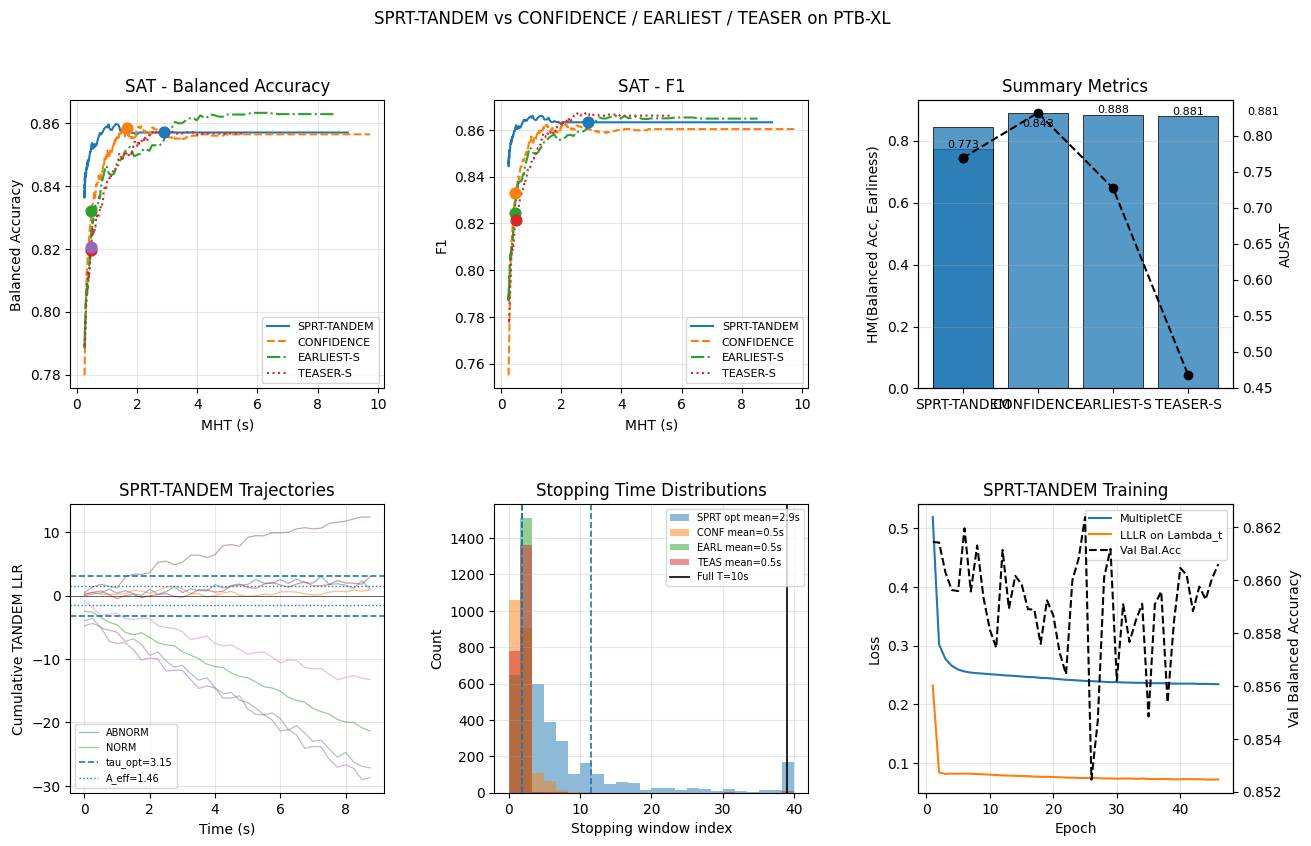

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.subplots_adjust(hspace=0.40, wspace=0.35)

def mht2s(mhts):
    return np.array(mhts) * WIN_STRIDE / FS

# SAT - balanced accuracy
ax = axes[0, 0]
ax.plot(mht2s(mh_t), ba_t,  label='SPRT-TANDEM')
ax.plot(mht2s(mh_ct), ba_ct, '--', label='CONFIDENCE')
ax.plot(mht2s(mh_et), ba_et, '-.', label='EARLIEST-S')
ax.plot(mht2s(mh_tt), ba_tt, ':',  label='TEASER-S')
for preds, hts in [(p_opt, ht_opt), (p_wal, ht_wal),
                    (p_con, ht_con), (p_ear, ht_ear), (p_tea, ht_tea)]:
    ax.scatter(np.mean(hts) * WIN_STRIDE / FS,
               balanced_accuracy_score(y_test, preds), s=60, zorder=5)
ax.set_xlabel('MHT (s)'); ax.set_ylabel('Balanced Accuracy')
ax.set_title('SAT - Balanced Accuracy'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

# SAT - F1
_, _, _, f1_ct = sat_upper(sm_t.max(-1),  pr_t,  lb_t)
_, _, _, f1_et = sat_upper(ht_t,           pg_t,  lbt_t)
_, _, _, f1_tt = sat_upper(st_t,           ps_t,  lbst_t)
ax = axes[0, 1]
ax.plot(mht2s(mh_t),  f1_t,  label='SPRT-TANDEM')
ax.plot(mht2s(mh_ct), f1_ct, '--', label='CONFIDENCE')
ax.plot(mht2s(mh_et), f1_et, '-.', label='EARLIEST-S')
ax.plot(mht2s(mh_tt), f1_tt, ':',  label='TEASER-S')
for preds, hts in [(p_opt, ht_opt), (p_con, ht_con),
                    (p_ear, ht_ear), (p_tea, ht_tea)]:
    ax.scatter(np.mean(hts) * WIN_STRIDE / FS,
               f1_score(y_test, preds, zero_division=0), s=60, zorder=5)
ax.set_xlabel('MHT (s)'); ax.set_ylabel('F1')
ax.set_title('SAT - F1'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

# HM and AUSAT bar chart
ax = axes[0, 2]
names  = [m.split()[0] for m in df.index]
hm_v   = df['HM(Ba,E)'].values
aus_v  = df['AUSAT'].values
ax.bar(names, hm_v, alpha=0.75, edgecolor='k', linewidth=0.7)
ax2 = ax.twinx()
ax2.plot(names, aus_v, 'k--o', markersize=6)
ax2.set_ylabel('AUSAT')
ax.set_ylabel('HM(Balanced Acc, Earliness)')
ax.set_title('Summary Metrics')
ax.grid(alpha=0.3, axis='y')
for i_b, v in enumerate(hm_v):
    ax.text(i_b, v + 0.003, f'{v:.3f}', ha='center', fontsize=8)

# TANDEM LLR trajectories
ax = axes[1, 0]
rng_v = np.random.default_rng(5)
shown = {0: 0, 1: 0}
t_ax  = np.arange(EFF_T) * WIN_STRIDE / FS
for i in rng_v.permutation(len(llrs_tst)):
    cls = int(lbs_tst[i])
    if shown[cls] >= 4:
        continue
    label = ('NORM' if shown[cls] == 0 and cls == 0 else
             'ABNORM' if shown[cls] == 0 and cls == 1 else None)
    ax.plot(t_ax, llrs_tst[i], alpha=0.5, lw=0.9, label=label)
    shown[cls] += 1
    if shown[0] >= 4 and shown[1] >= 4:
        break
ax.axhline(+TAU_OPT, ls='--', lw=1.2, label=f'tau_opt={TAU_OPT:.2f}')
ax.axhline(-TAU_OPT, ls='--', lw=1.2)
ax.axhline(+A_EFF, ls=':', lw=1.0, label=f'A_eff={A_EFF:.2f}')
ax.axhline( B_EFF, ls=':', lw=1.0)
ax.axhline(0, color='k', lw=0.4)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Cumulative TANDEM LLR')
ax.set_title('SPRT-TANDEM Trajectories')
ax.legend(fontsize=7); ax.grid(alpha=0.3)

# Stopping time distributions
ax = axes[1, 1]
bins = np.linspace(0, T + 1, 25)
for label, hts in [('SPRT opt', ht_opt), ('CONF', ht_con),
                    ('EARL', ht_ear), ('TEAS', ht_tea)]:
    mu = np.mean(hts) * WIN_STRIDE / FS
    ax.hist(hts, bins=bins, alpha=0.5, label=f'{label} mean={mu:.1f}s')
    ax.axvline(np.mean(hts), ls='--', lw=1.2)
ax.axvline(T, color='k', lw=1.2, label=f'Full T={T * WIN_STRIDE / FS:.0f}s')
ax.set_xlabel('Stopping window index')
ax.set_ylabel('Count')
ax.set_title('Stopping Time Distributions')
ax.legend(fontsize=7); ax.grid(alpha=0.3)

# Training loss curves
ax = axes[1, 2]
ep_ax = range(1, len(hist_i['loss']) + 1)
ax.plot(ep_ax, hist_i['mce'],  label='MultipletCE')
ax.plot(ep_ax, hist_i['lllr'], label='LLLR on Lambda_t')
ax2 = ax.twinx()
ax2.plot(ep_ax, hist_i['vb'], 'k--', label='Val Bal.Acc')
ax2.set_ylabel('Val Balanced Accuracy')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('SPRT-TANDEM Training')
lines = ax.get_lines() + ax2.get_lines()
ax.legend(lines, [l.get_label() for l in lines], fontsize=8)
ax.grid(alpha=0.3)

fig.suptitle('SPRT-TANDEM vs CONFIDENCE / EARLIEST / TEASER on PTB-XL', fontsize=12)
plt.savefig('sprt_final.png', dpi=130, bbox_inches='tight')
plt.show()
